# FRIDA Veri Seti Analizi

## TÜBİTAK 2209-A

**Proje:** Transfer Öğrenme Temelli CNN Mimarilerinin Görüş Mesafesi Tahmininde Karşılaştırmalı Analizi

### Amaç

Bu notebook, FRIDA veri setinin dosya yapısını ve temel teknik özelliklerini incelemek amacıyla hazırlanmıştır.

Bu aşamada:

- veri seti üzerinde değişiklik yapılmaz,
- ön işleme uygulanmaz,
- model eğitimi gerçekleştirilmez,
- yalnızca veri bütünlüğü ve veri yapısı analiz edilir.


## Beklenen Veri Seti Özeti

| Özellik | Beklenen değer |
|---|---:|
| Veri seti | FRIDA |
| PNG görüntüsü | 90 |
| Derinlik dosyası | 18 |
| Görüntü çözünürlüğü | 640 × 480 |
| Görüntü biçimi | PNG |
| Derinlik biçimi | FDD |
| Kullanım amacı | Araştırma |


## Klasör Yapısı

```text
fog-visibility-estimation/
├── data/
│   └── raw/
│       └── frida/
│           ├── *.png
│           ├── *.fdd
│           ├── *.txt
│           └── *.m
└── notebooks/
    └── dataset_analysis.ipynb
```


## 1. Kütüphanelerin İçe Aktarılması


In [1]:
from pathlib import Path
from collections import Counter

from PIL import Image
import matplotlib.pyplot as plt

print("Kütüphaneler başarıyla yüklendi.")

Kütüphaneler başarıyla yüklendi.


## 2. Veri Seti Yolunun Belirlenmesi


In [2]:
# Notebook proje içindeki notebooks/ klasöründeyse göreli yol kullanılır.
# VS Code farklı bir çalışma dizini seçerse Windows yolu yedek olarak kullanılır.
relative_path = Path("../data/raw/frida")
absolute_path = Path(r"C:\projects\fog-visibility-estimation\data\raw\frida")

DATASET_PATH = relative_path if relative_path.exists() else absolute_path

print("Veri seti yolu:", DATASET_PATH.resolve())
print("Klasör mevcut mu?:", DATASET_PATH.exists())

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        "FRIDA klasörü bulunamadı. DATASET_PATH değerini kendi klasör yapınıza göre güncelleyin."
    )

Veri seti yolu: C:\projects\fog-visibility-estimation\data\raw\frida
Klasör mevcut mu?: True


## 3. Toplam Dosya Sayısı ve Dosya Türleri


In [3]:
all_files = sorted(path for path in DATASET_PATH.iterdir() if path.is_file())
extensions = Counter(path.suffix.lower() for path in all_files)

print("Toplam dosya sayısı:", len(all_files))
print("Dosya türleri:", extensions)

Toplam dosya sayısı: 112
Dosya türleri: Counter({'.png': 90, '.fdd': 18, '.txt': 3, '.m': 1})


## 4. PNG ve FDD Dosyalarının Belirlenmesi


In [4]:
png_files = sorted(DATASET_PATH.glob("*.png"))
fdd_files = sorted(DATASET_PATH.glob("*.fdd"))
txt_files = sorted(DATASET_PATH.glob("*.txt"))
matlab_files = sorted(DATASET_PATH.glob("*.m"))

print("PNG görüntü sayısı:", len(png_files))
print("FDD dosyası sayısı:", len(fdd_files))
print("TXT dosyası sayısı:", len(txt_files))
print("MATLAB dosyası sayısı:", len(matlab_files))

if not png_files:
    raise RuntimeError("Klasörde PNG görüntüsü bulunamadı.")

PNG görüntü sayısı: 90
FDD dosyası sayısı: 18
TXT dosyası sayısı: 3
MATLAB dosyası sayısı: 1


## 5. Örnek Görüntünün Açılması


Dosya adı: K080-000001.png
Boyut: (640, 480)
Renk modu: RGB


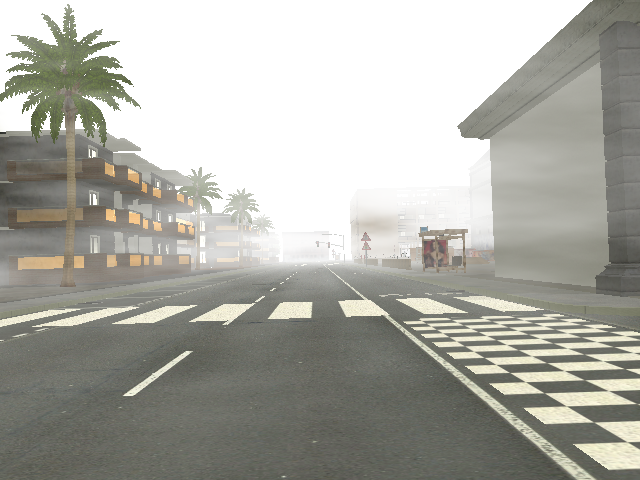

In [5]:
with Image.open(png_files[0]) as sample_image:
    sample = sample_image.copy()

print("Dosya adı:", png_files[0].name)
print("Boyut:", sample.size)
print("Renk modu:", sample.mode)

display(sample)

## 6. İlk Altı Görüntünün Görselleştirilmesi


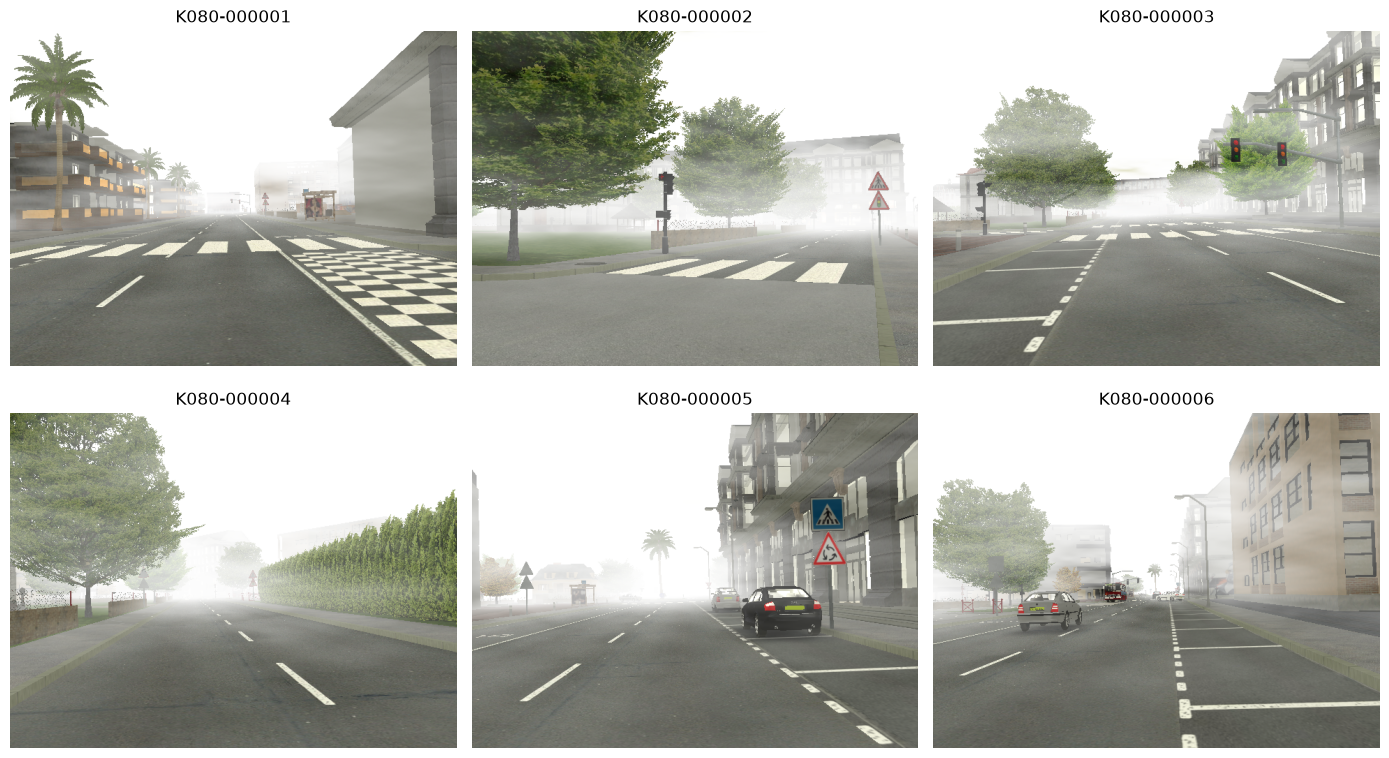

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, image_path in zip(axes.flatten(), png_files[:6]):
    with Image.open(image_path) as image:
        ax.imshow(image)
    ax.set_title(image_path.stem)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 7. Çözünürlük Dağılımı


In [7]:
resolution_counts = Counter()

for image_path in png_files:
    with Image.open(image_path) as image:
        resolution_counts[image.size] += 1

print("Çözünürlük dağılımı:")
for resolution, count in resolution_counts.items():
    print(f"- {resolution[0]} × {resolution[1]}: {count} görüntü")

Çözünürlük dağılımı:
- 640 × 480: 90 görüntü


## 8. Renk Modu Dağılımı


In [8]:
mode_counts = Counter()

for image_path in png_files:
    with Image.open(image_path) as image:
        mode_counts[image.mode] += 1

print("Renk modu dağılımı:")
for mode, count in mode_counts.items():
    print(f"- {mode}: {count} görüntü")

Renk modu dağılımı:
- RGB: 90 görüntü


## 9. Görüntü Dosyası Öneklerinin Analizi


In [9]:
# Dosya adının ilk karakteri görüntü gruplarını genel düzeyde karşılaştırmak için kullanılır.
prefix_counts = Counter(image_path.stem[0] for image_path in png_files)

print("Dosya adı önekleri:")
for prefix, count in sorted(prefix_counts.items()):
    print(f"- {prefix}: {count} görüntü")

Dosya adı önekleri:
- K: 18 görüntü
- L: 36 görüntü
- M: 18 görüntü
- U: 18 görüntü


## 10. Dosya Adı Örnekleri


In [10]:
print("İlk 20 PNG dosyası:")
for image_path in png_files[:20]:
    print(image_path.name)

İlk 20 PNG dosyası:
K080-000001.png
K080-000002.png
K080-000003.png
K080-000004.png
K080-000005.png
K080-000006.png
K080-000007.png
K080-000008.png
K080-000009.png
K080-000010.png
K080-000011.png
K080-000012.png
K080-000013.png
K080-000014.png
K080-000015.png
K080-000016.png
K080-000017.png
K080-000018.png
L080-000001.png
L080-000002.png


## 11. FDD Dosyalarının Listelenmesi


In [11]:
print("FDD dosyaları:")
for fdd_path in fdd_files:
    print(fdd_path.name)

FDD dosyaları:
Dmap-000001.fdd
Dmap-000002.fdd
Dmap-000003.fdd
Dmap-000004.fdd
Dmap-000005.fdd
Dmap-000006.fdd
Dmap-000007.fdd
Dmap-000008.fdd
Dmap-000009.fdd
Dmap-000010.fdd
Dmap-000011.fdd
Dmap-000012.fdd
Dmap-000013.fdd
Dmap-000014.fdd
Dmap-000015.fdd
Dmap-000016.fdd
Dmap-000017.fdd
Dmap-000018.fdd


## 12. Bozuk Görüntü Kontrolü


In [12]:
corrupted_images = []

for image_path in png_files:
    try:
        with Image.open(image_path) as image:
            image.verify()
    except (OSError, ValueError) as error:
        corrupted_images.append((image_path.name, str(error)))

if corrupted_images:
    print("Bozuk veya okunamayan görüntüler:")
    for filename, error in corrupted_images:
        print(f"- {filename}: {error}")
else:
    print("Bozuk veya okunamayan PNG görüntüsü bulunmadı.")

Bozuk veya okunamayan PNG görüntüsü bulunmadı.


## 13. Etiket ve Metadata İncelemesi

- Veri setinde `labels.csv`, `annotations.json` veya benzeri hazır bir regresyon etiketi dosyası bulunmamaktadır.
- `ImageOwners.txt`, veri setinin sahiplik ve araştırma amaçlı kullanım koşullarını açıklamaktadır.
- Görüş mesafesi regresyon hedeflerinin, araştırma önerisinde belirtildiği üzere derinlik bilgileri ve veri üretim yapısı temel alınarak oluşturulması gerekmektedir.
- `.fdd` dosyaları standart görüntü dosyaları değildir; bu aşamada yalnızca varlıkları ve dosya adları doğrulanmıştır.


## 14. Otomatik Teknik Özet


In [13]:
expected_counts = {
    ".png": 90,
    ".fdd": 18,
    ".txt": 3,
    ".m": 1,
}

print("FRIDA TEKNİK ÖZETİ")
print("-" * 40)
print(f"Toplam dosya: {len(all_files)}")
print(f"PNG görüntüsü: {len(png_files)}")
print(f"FDD dosyası: {len(fdd_files)}")
print(f"Bozuk PNG görüntüsü: {len(corrupted_images)}")
print(f"Çözünürlük türü sayısı: {len(resolution_counts)}")
print(f"Renk modu türü sayısı: {len(mode_counts)}")

count_check = all(extensions.get(ext, 0) == count for ext, count in expected_counts.items())
resolution_check = resolution_counts == Counter({(640, 480): 90})
mode_check = mode_counts == Counter({"RGB": 90})
integrity_check = not corrupted_images

print("\nKontroller")
print("- Beklenen dosya dağılımı:", "UYGUN" if count_check else "KONTROL GEREKLİ")
print("- Beklenen çözünürlük dağılımı:", "UYGUN" if resolution_check else "KONTROL GEREKLİ")
print("- Beklenen renk modu dağılımı:", "UYGUN" if mode_check else "KONTROL GEREKLİ")
print("- Görüntü bütünlüğü:", "UYGUN" if integrity_check else "KONTROL GEREKLİ")

FRIDA TEKNİK ÖZETİ
----------------------------------------
Toplam dosya: 112
PNG görüntüsü: 90
FDD dosyası: 18
Bozuk PNG görüntüsü: 0
Çözünürlük türü sayısı: 1
Renk modu türü sayısı: 1

Kontroller
- Beklenen dosya dağılımı: UYGUN
- Beklenen çözünürlük dağılımı: UYGUN
- Beklenen renk modu dağılımı: UYGUN
- Görüntü bütünlüğü: UYGUN


# Sonuç

Day 3 kapsamında FRIDA veri seti indirilmiş ve temel teknik analizi tamamlanmıştır.

Elde edilen bulgular:

- veri setinde 90 PNG görüntüsü bulunmaktadır,
- 18 adet `.fdd` derinlik dosyası bulunmaktadır,
- görüntüler 640 × 480 çözünürlüğündedir,
- görüntüler RGB renk modundadır,
- bozuk PNG görüntüsü bulunmamaktadır,
- hazır sürekli görüş mesafesi etiketi bulunmamaktadır,
- veri seti sonraki veri hazırlama çalışmalarına geçmek için teknik olarak uygun görünmektedir.

Bu notebook, ilerleyen aşamalarda gerçekleştirilecek ön işleme ve regresyon etiketi oluşturma çalışmalarının başlangıç referansıdır.
